In [5]:
import pandas as pd
import numpy as np
import plotly.express as px

print("Setup complete! All libraries imported successfully.")


Setup complete! All libraries imported successfully.


In [6]:

import pandas as pd

# Load the first 100,000 rows quickly
df = pd.read_csv('2019-Nov.csv', nrows=100000)

# Display the first few rows and column info
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (100000, 9)


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:00 UTC,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33
1,2019-11-01 00:00:00 UTC,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283
2,2019-11-01 00:00:01 UTC,view,17302664,2053013553853497655,NaN,creed,28.31,561587266,755422e7-9040-477b-9bd2-6a6e8fd97387
3,2019-11-01 00:00:01 UTC,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f
4,2019-11-01 00:00:01 UTC,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2


In [7]:
# Check unique event types and their counts
event_counts = df['event_type'].value_counts()
print("Event Counts:\n", event_counts)

Event Counts:
 event_type
view        97489
purchase     1422
cart         1089
Name: count, dtype: int64


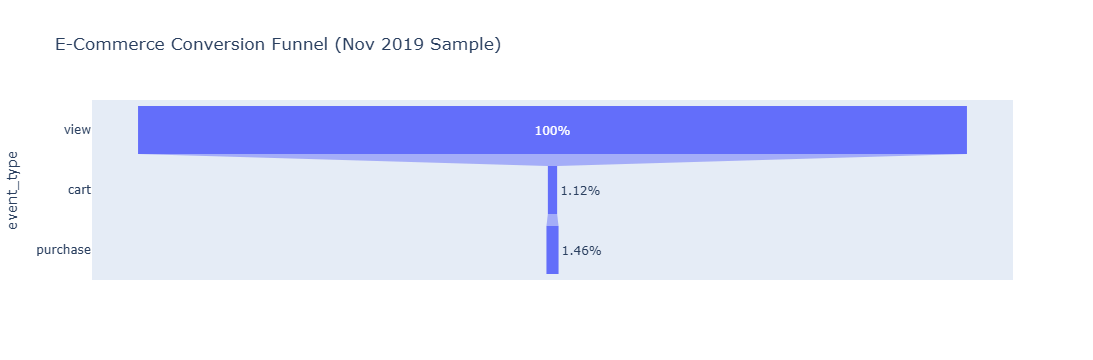

In [9]:
import plotly.express as px

# Reorder stages logically: view -> cart -> purchase
funnel_order = ['view', 'cart', 'purchase']
funnel_df = event_counts.reindex(funnel_order).reset_index()
funnel_df.columns = ['event_type', 'count']

# Calculate conversion rate from total views
funnel_df['conversion_rate (%)'] = ((funnel_df['count'] / funnel_df['count'].iloc[0]) * 100).round(2)

# Plot interactive funnel
fig = px.funnel(
    funnel_df, 
    x='count', 
    y='event_type', 
    text='conversion_rate (%)',
    title="E-Commerce Conversion Funnel (Nov 2019 Sample)"
)

fig.update_traces(texttemplate='%{text}%')
fig.show()

In [10]:
# Unique users at each stage
unique_users = df.groupby('event_type')['user_id'].nunique().reindex(['view', 'cart', 'purchase']).reset_index()
unique_users.columns = ['stage', 'unique_users']
unique_users['conversion_rate (%)'] = ((unique_users['unique_users'] / unique_users['unique_users'].iloc[0]) * 100).round(2)

print("Unique User Funnel:")
print(unique_users)

Unique User Funnel:
      stage  unique_users  conversion_rate (%)
0      view         20774               100.00
1      cart           685                 3.30
2  purchase          1159                 5.58


In [11]:
# Top 5 revenue-generating brands
purchases = df[df['event_type'] == 'purchase']
top_brands = purchases.groupby('brand')['price'].sum().nlargest(5).reset_index()

print("Top 5 Brands by Sales Revenue:")
print(top_brands)

Top 5 Brands by Sales Revenue:
     brand      price
0    apple  182829.52
1  samsung   80901.85
2   xiaomi   19221.07
3   huawei    8663.00
4     sony    7456.61


In [12]:
# Category performance breakdown
category_perf = df.groupby(['category_code', 'event_type']).size().unstack(fill_value=0)
if 'purchase' in category_perf.columns and 'view' in category_perf.columns:
    category_perf['conversion_rate (%)'] = (category_perf['purchase'] / category_perf['view'] * 100).round(2)
    print("Top 10 Categories by Purchase Volume:")
    print(category_perf.sort_values(by='purchase', ascending=False).head(10))
    

Top 10 Categories by Purchase Volume:
event_type                        cart  purchase   view  conversion_rate (%)
category_code                                                               
electronics.smartphone             673       624  23631                 2.64
electronics.audio.headphone         75        78   2660                 2.93
electronics.video.tv                34        44   2654                 1.66
appliances.kitchen.washer            5        35   1859                 1.88
electronics.clocks                  15        31   2614                 1.19
appliances.kitchen.refrigerators     9        26   1767                 1.47
appliances.environment.vacuum       16        21   1905                 1.10
computers.notebook                   9        15   2444                 0.61
electronics.tablet                  15        13    696                 1.87
computers.desktop                    0        13   1157                 1.12


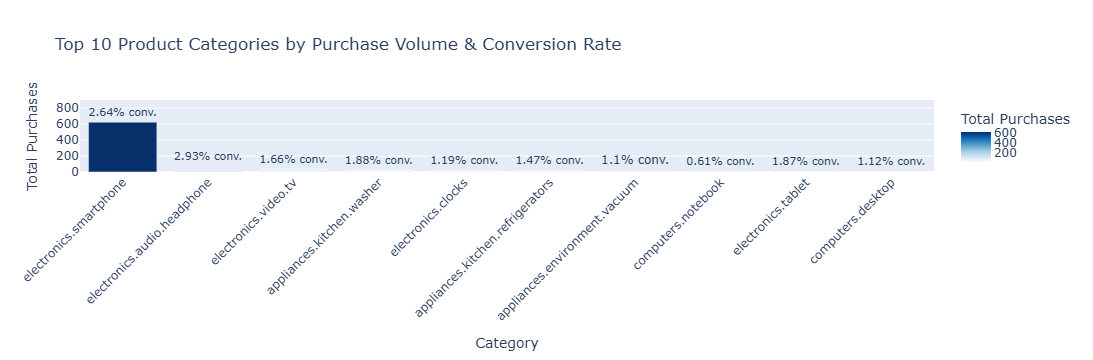

In [13]:
import plotly.express as px

# Prepare top categories dataframe
top_cat_df = category_perf.sort_values(by='purchase', ascending=False).head(10).reset_index()

# Plot purchases by category
fig_cat = px.bar(
    top_cat_df, 
    x='category_code', 
    y='purchase',
    text='conversion_rate (%)',
    title="Top 10 Product Categories by Purchase Volume & Conversion Rate",
    labels={'category_code': 'Category', 'purchase': 'Total Purchases'},
    color='purchase',
    color_continuous_scale='Blues'
)

fig_cat.update_traces(texttemplate='%{text}% conv.', textposition='outside')
fig_cat.update_layout(xaxis_tickangle=-45)
fig_cat.show()

In [14]:
# Calculate drop-off rates
views = unique_users.loc[unique_users['stage'] == 'view', 'unique_users'].values[0]
carts = unique_users.loc[unique_users['stage'] == 'cart', 'unique_users'].values[0]
purchases = unique_users.loc[unique_users['stage'] == 'purchase', 'unique_users'].values[0]

view_to_cart_drop = round(((views - carts) / views) * 100, 2)
cart_to_purchase_drop = round(((carts - purchases) / carts) * 100, 2) if carts > 0 else 0

print("--- Funnel Drop-off Analysis ---")
print(f"Drop-off from View -> Cart: {view_to_cart_drop}%")
print(f"Drop-off from Cart -> Purchase: {cart_to_purchase_drop}%")

--- Funnel Drop-off Analysis ---
Drop-off from View -> Cart: 96.7%
Drop-off from Cart -> Purchase: -69.2%


In [15]:
# Save summary table to CSV
unique_users.to_csv('funnel_summary.csv', index=False)

# Save interactive charts as HTML
fig.write_html("funnel_chart.html")
fig_cat.write_html("category_performance.html")

print("Files exported successfully to your project folder!")

Files exported successfully to your project folder!
